# SOC_MC Playground
**Interactive pipeline for pretraining, stability runs, evaluation, and visualization.**

Change the config cells below to run your own ablation experiments.

In [24]:
import sys, os, torch, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/home/sky/SML/SOC_MC")
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from model.train import load_sampler, load_benchmark, evaluate_mode_weights, build_optimizer, seed_everything
from model.adjoint_sampling import AdjointSampling
from model.asbs import ASBS

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Configuration
Edit this cell to change benchmark, sampler, subset, and training params.

In [55]:
# ====== EDIT THIS CELL ======

# Sampler: "as" or "asbs"
SAMPLER_NAME = "as"
MODEL_CONFIG = "model/configs/as_default.yaml"

# Benchmark: "w5", "c5", or "b5"
BENCH_NAME = "b5"
BENCH_CONFIG = f"benchmark/configs/{BENCH_NAME}.yaml"

# Subset for pretraining (0-indexed mode indices)
SUBSET_S = [0, 1]  # e.g. [0], [0,1], [0,1,2], [3,4]

# Training
PRETRAIN_EPOCHS = 500
STABILITY_EPOCHS = 200
BATCH_SIZE = 256
LR = 1e-4            # None = use config default
SEED = 0

# Eval
N_EVAL = 10000
EVAL_EVERY = 20  # during stability run

## 2. Load Sampler & Benchmark

In [56]:
seed_everything(SEED)

# Load sampler
sampler, model_cfg = load_sampler(MODEL_CONFIG)
sampler = sampler.to(device)
n_params = sum(p.numel() for p in sampler.parameters())
print(f"Sampler: {sampler.__class__.__name__}, params: {n_params:,}")

# Load benchmark (full target)
energy_fn = load_benchmark(BENCH_CONFIG)
print(f"Benchmark: {energy_fn.__class__.__name__}, K={energy_fn.K}, dim={energy_fn.dim}")
print(f"Mode weights: {energy_fn.mode_weights}")
print(f"Mode centers:\n{energy_fn.mode_centers}")

# Restricted target for pretraining
energy_fn_S = energy_fn.restricted(SUBSET_S)
print(f"\nRestricted to S={SUBSET_S}, weights: {energy_fn_S.mode_weights}")

Sampler: AdjointSampling, params: 83,330
Benchmark: B5Energy, K=5, dim=2
Mode weights: tensor([0.2000, 0.2000, 0.2000, 0.2000, 0.2000])
Mode centers:
tensor([[ -3.,   0.],
        [  0.,   0.],
        [  3.,   0.],
        [  0.,  12.],
        [  0., -12.]])

Restricted to S=[0, 1], weights: tensor([0.5000, 0.5000])


## 3. Visualize Target Distribution
Plot the full target and restricted target side by side.

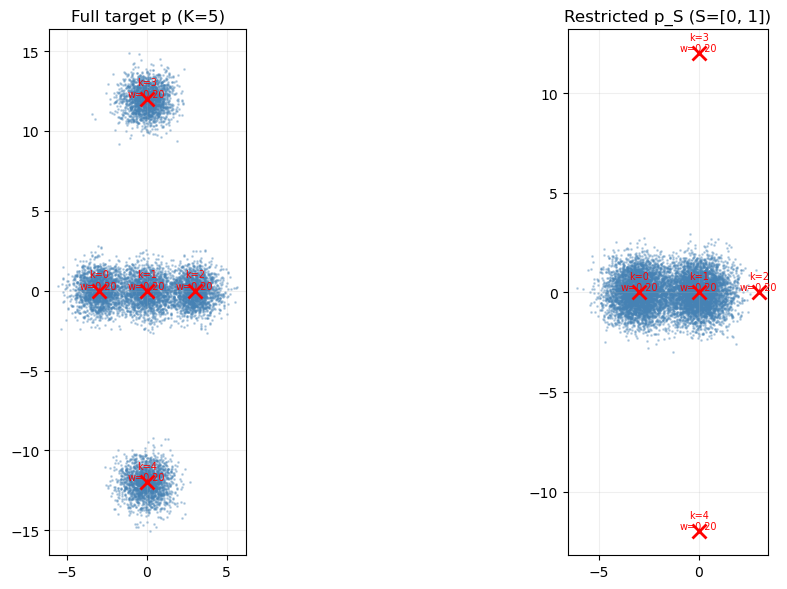

In [57]:
def plot_2d_samples(samples, energy_fn, title="", ax=None, s=1, alpha=0.3):
    """Scatter plot of 2D samples with mode centers marked."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    x = samples[:, 0].cpu().numpy()
    y = samples[:, 1].cpu().numpy()
    ax.scatter(x, y, s=s, alpha=alpha, c='steelblue', rasterized=True)
    # Mark mode centers
    centers = energy_fn.mode_centers.cpu().numpy()
    weights = energy_fn.mode_weights.cpu().numpy() if hasattr(energy_fn.mode_weights, 'cpu') else np.array(energy_fn.mode_weights)
    for k, (cx, cy) in enumerate(centers):
        ax.plot(cx, cy, 'rx', markersize=10, markeredgewidth=2)
        ax.annotate(f"k={k}\nw={weights[k]:.2f}", (cx, cy), fontsize=7,
                    ha='center', va='bottom', color='red')
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    return ax

# Reference samples
ref_full = energy_fn.get_ref_samples(N_EVAL).to(device)
ref_S = energy_fn_S.get_ref_samples(N_EVAL).to(device)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_2d_samples(ref_full, energy_fn, f"Full target p (K={energy_fn.K})", ax=axes[0])
plot_2d_samples(ref_S, energy_fn, f"Restricted p_S (S={SUBSET_S})", ax=axes[1])
plt.tight_layout()
plt.show()

## 4. Pre-train on Restricted Target p_S
Train the sampler to approximate p_S (mode-collapsed state).

In [58]:
optimizer = build_optimizer(sampler, model_cfg)
if LR is not None:
    for pg in optimizer.param_groups:
        pg["lr"] = LR

is_asbs = isinstance(sampler, ASBS)
pretrain_losses = []

for epoch in range(PRETRAIN_EPOCHS):
    sampler.train()
    if is_asbs:
        sampler.set_init_stage(epoch < 50)
        optimizer.zero_grad()
        loss = sampler.train_step(BATCH_SIZE, energy_fn_S, device, step_type="corrector")
        loss.backward(); optimizer.step()
        optimizer.zero_grad()
        loss = sampler.train_step(BATCH_SIZE, energy_fn_S, device, step_type="adjoint")
        loss.backward(); optimizer.step()
    else:
        optimizer.zero_grad()
        loss = sampler.train_step(BATCH_SIZE, energy_fn_S, device)
        loss.backward(); optimizer.step()

    pretrain_losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"Pretrain epoch {epoch+1}/{PRETRAIN_EPOCHS}: loss={loss.item():.4f}")

L_S_star = np.mean(pretrain_losses[-10:])
print(f"\nL_S* = {L_S_star:.4f}")

# Save checkpoint
pretrain_ckpt = sampler.state_dict()
print("Pretrain checkpoint saved (in memory)")

Pretrain epoch 100/500: loss=1.6573
Pretrain epoch 200/500: loss=0.6921
Pretrain epoch 300/500: loss=0.7208
Pretrain epoch 400/500: loss=0.6250
Pretrain epoch 500/500: loss=0.5272

L_S* = 0.5250
Pretrain checkpoint saved (in memory)


## 5. Visualize Pre-trained (Collapsed) Samples

Mode weights after pretrain: ['0.428', '0.546', '0.026', '0.000', '0.000']
MWD = 0.3463


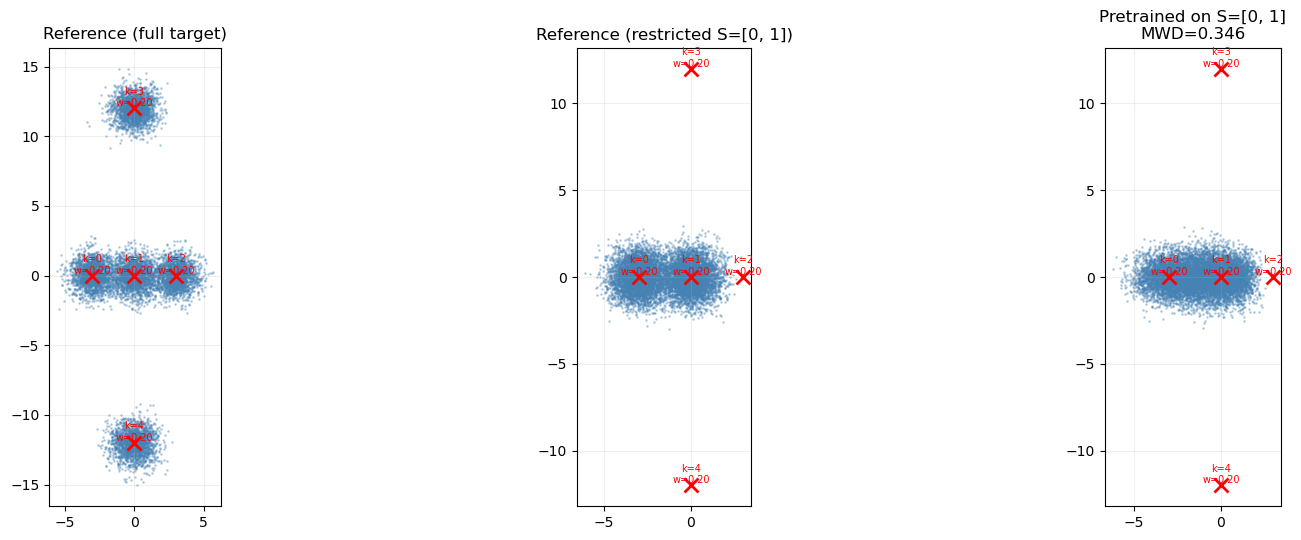

In [59]:
sampler.eval()
with torch.no_grad():
    samples_pretrain = sampler.sample(N_EVAL, device)

alphas_pre, mwd_pre = evaluate_mode_weights(sampler, energy_fn, N_EVAL, device)
print(f"Mode weights after pretrain: {[f'{a:.3f}' for a in alphas_pre]}")
print(f"MWD = {mwd_pre:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
plot_2d_samples(ref_full, energy_fn, "Reference (full target)", ax=axes[0])
plot_2d_samples(ref_S, energy_fn, f"Reference (restricted S={SUBSET_S})", ax=axes[1])
plot_2d_samples(samples_pretrain, energy_fn, f"Pretrained on S={SUBSET_S}\nMWD={mwd_pre:.3f}", ax=axes[2])
plt.tight_layout()
plt.show()

## 6. Stability Run on Full Target
Resume training on the full target from the collapsed checkpoint. Track mode weights over epochs.

In [60]:
# Reload from pretrain checkpoint
sampler.load_state_dict(pretrain_ckpt)
optimizer = build_optimizer(sampler, model_cfg)
if LR is not None:
    for pg in optimizer.param_groups:
        pg["lr"] = LR

stability_losses = []
stability_alphas = []   # list of (epoch, [alpha_1,...,alpha_K], mwd)
stability_samples = {}  # epoch -> samples tensor

for epoch in range(STABILITY_EPOCHS):
    sampler.train()
    if is_asbs:
        sampler.set_init_stage(False)
        optimizer.zero_grad()
        loss = sampler.train_step(BATCH_SIZE, energy_fn, device, step_type="corrector")
        loss.backward(); optimizer.step()
        optimizer.zero_grad()
        loss = sampler.train_step(BATCH_SIZE, energy_fn, device, step_type="adjoint")
        loss.backward(); optimizer.step()
    else:
        optimizer.zero_grad()
        loss = sampler.train_step(BATCH_SIZE, energy_fn, device)
        loss.backward(); optimizer.step()

    stability_losses.append(loss.item())

    # Eval at intervals
    if (epoch + 1) % EVAL_EVERY == 0:
        sampler.eval()
        alphas, mwd = evaluate_mode_weights(sampler, energy_fn, N_EVAL, device)
        stability_alphas.append((epoch + 1, alphas, mwd))
        print(f"  Epoch {epoch+1}: loss={loss.item():.4f}, MWD={mwd:.4f}, "
              f"alpha={[f'{a:.3f}' for a in alphas]}")

        # Save samples at key epochs
        if (epoch + 1) in [20, 50, 100, 200]:
            with torch.no_grad():
                stability_samples[epoch + 1] = sampler.sample(N_EVAL, device).cpu()

print(f"\nDone. Final MWD = {stability_alphas[-1][2]:.4f}")

  Epoch 20: loss=0.6640, MWD=0.2919, alpha=['0.402', '0.492', '0.106', '0.000', '0.000']
  Epoch 40: loss=0.6305, MWD=0.2209, alpha=['0.388', '0.421', '0.191', '0.000', '0.000']
  Epoch 60: loss=0.6460, MWD=0.2000, alpha=['0.399', '0.391', '0.210', '0.000', '0.000']
  Epoch 80: loss=0.5458, MWD=0.2059, alpha=['0.406', '0.372', '0.222', '0.000', '0.000']
  Epoch 100: loss=0.5617, MWD=0.2233, alpha=['0.423', '0.362', '0.214', '0.000', '0.000']
  Epoch 120: loss=0.5452, MWD=0.2421, alpha=['0.442', '0.337', '0.221', '0.000', '0.000']
  Epoch 140: loss=0.4464, MWD=0.2425, alpha=['0.442', '0.318', '0.239', '0.000', '0.000']
  Epoch 160: loss=0.5580, MWD=0.2521, alpha=['0.452', '0.299', '0.248', '0.000', '0.000']
  Epoch 180: loss=0.4850, MWD=0.2627, alpha=['0.463', '0.267', '0.271', '0.000', '0.000']
  Epoch 200: loss=0.4329, MWD=0.2419, alpha=['0.442', '0.271', '0.287', '0.000', '0.000']

Done. Final MWD = 0.2419


## 7. Training Curves: Loss and Mode Weights

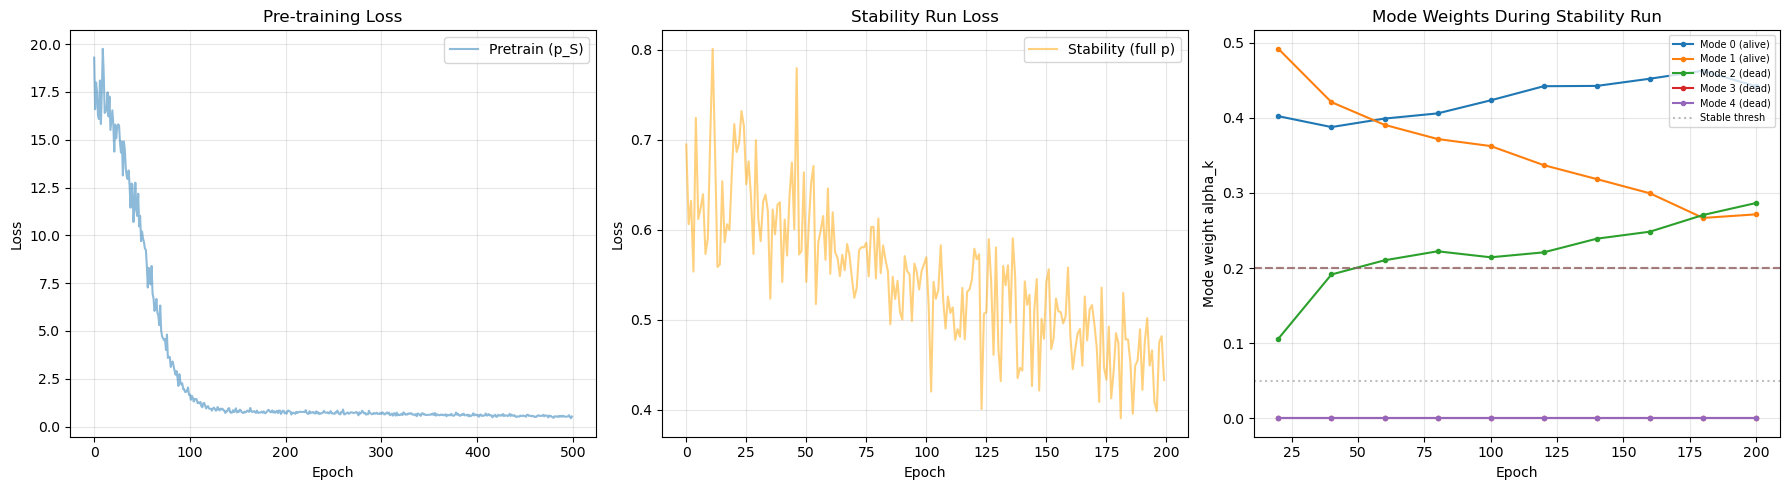


Stability classification: ESCAPED


In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
ax = axes[0]
ax.plot(pretrain_losses, alpha=0.5, label="Pretrain (p_S)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Pre-training Loss")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(stability_losses, alpha=0.5, color='orange', label="Stability (full p)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Stability Run Loss")
ax.legend(); ax.grid(True, alpha=0.3)

# Mode weights over stability run
ax = axes[2]
epochs_eval = [e for e, a, m in stability_alphas]
K = energy_fn.K
ref_weights = energy_fn.mode_weights.cpu().numpy() if hasattr(energy_fn.mode_weights, 'cpu') else np.array(energy_fn.mode_weights)
colors = plt.cm.tab10(np.arange(K))
for k in range(K):
    alphas_k = [a[k] for _, a, _ in stability_alphas]
    label = f"Mode {k}" + (" (dead)" if k not in SUBSET_S else " (alive)")
    ax.plot(epochs_eval, alphas_k, '-o', color=colors[k], markersize=3, label=label)
    ax.axhline(ref_weights[k], color=colors[k], linestyle='--', alpha=0.3)
ax.axhline(0.05, color='gray', linestyle=':', alpha=0.5, label='Stable thresh')
ax.set_xlabel("Epoch"); ax.set_ylabel("Mode weight alpha_k")
ax.set_title("Mode Weights During Stability Run"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Classification
mwd_vals = [m for _, _, m in stability_alphas]
if all(m < 0.05 for m in mwd_vals[1:]):
    status = "STABLE"
elif sum(1 for i in range(len(mwd_vals)-2) if all(m > 0.15 for m in mwd_vals[i:i+3])) > 0:
    status = "ESCAPED"
else:
    status = "AMBIGUOUS"
print(f"\nStability classification: {status}")

## 8. Terminal Distribution Evolution
Sample scatter plots at epochs 0 (pretrain), 20, 50, 100, 200 compared to reference.

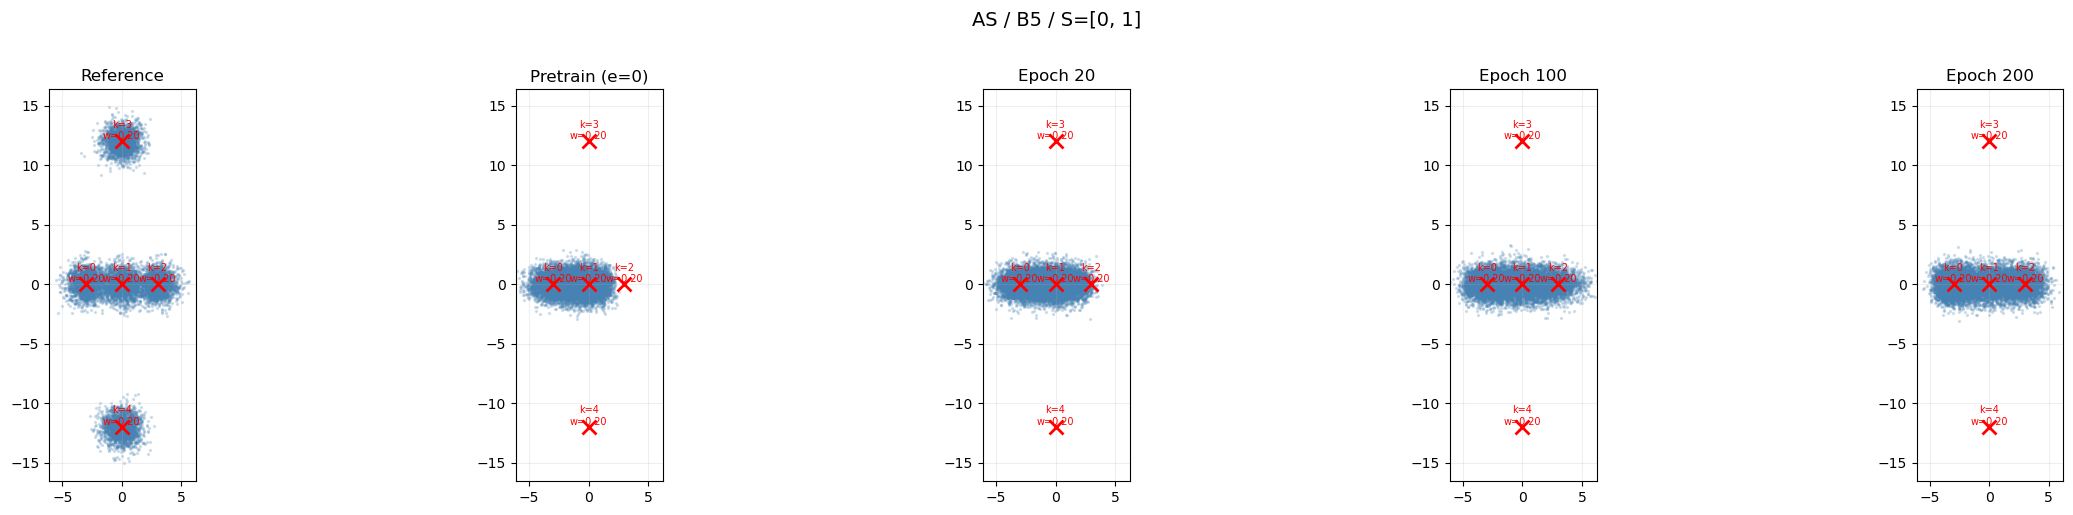

In [62]:
snapshots = {"Pretrain (e=0)": samples_pretrain.cpu()}
for e, samps in sorted(stability_samples.items()):
    snapshots[f"Epoch {e}"] = samps

n_panels = 1 + len(snapshots)  # reference + snapshots
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))

plot_2d_samples(ref_full, energy_fn, "Reference", ax=axes[0], s=2, alpha=0.2)
for i, (label, samps) in enumerate(snapshots.items()):
    plot_2d_samples(samps, energy_fn, label, ax=axes[i + 1], s=2, alpha=0.2)

# Shared axis limits
xlims = axes[0].get_xlim(); ylims = axes[0].get_ylim()
for ax in axes:
    ax.set_xlim(xlims); ax.set_ylim(ylims)

plt.suptitle(f"{SAMPLER_NAME.upper()} / {BENCH_NAME.upper()} / S={SUBSET_S}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Energy Landscape Contour + Samples Overlay

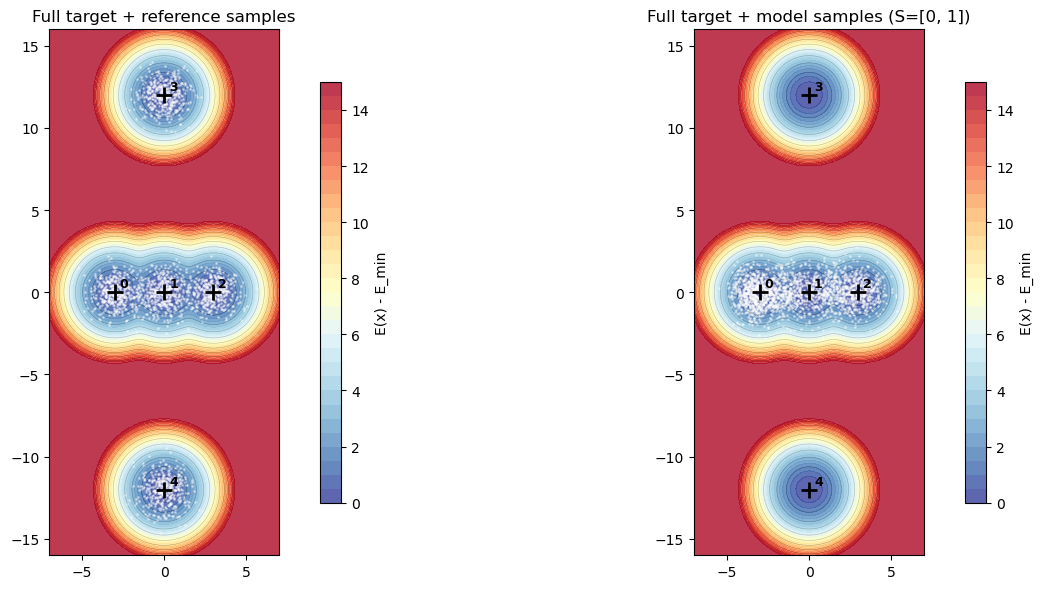

In [63]:
def plot_energy_contour(energy_fn, samples=None, ax=None, title="", grid_n=200, clamp_E=15):
    """Plot energy landscape as filled contours with optional sample overlay."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    centers = energy_fn.mode_centers.cpu().numpy()
    margin = 4.0
    xmin, xmax = centers[:, 0].min() - margin, centers[:, 0].max() + margin
    ymin, ymax = centers[:, 1].min() - margin, centers[:, 1].max() + margin

    xx, yy = np.meshgrid(np.linspace(xmin, xmax, grid_n), np.linspace(ymin, ymax, grid_n))
    grid = torch.tensor(np.stack([xx.ravel(), yy.ravel()], axis=1), dtype=torch.float32, device=device)
    with torch.no_grad():
        E = energy_fn.energy(grid).cpu().numpy().reshape(grid_n, grid_n)
    E = np.clip(E - E.min(), 0, clamp_E)

    cs = ax.contourf(xx, yy, E, levels=30, cmap='RdYlBu_r', alpha=0.8)
    ax.contour(xx, yy, E, levels=10, colors='k', alpha=0.2, linewidths=0.5)
    plt.colorbar(cs, ax=ax, label='E(x) - E_min', shrink=0.8)

    if samples is not None:
        x = samples[:2000, 0].cpu().numpy()
        y = samples[:2000, 1].cpu().numpy()
        ax.scatter(x, y, s=1, c='white', alpha=0.4, rasterized=True)

    for k, (cx, cy) in enumerate(centers):
        ax.plot(cx, cy, 'k+', markersize=12, markeredgewidth=2)
        ax.annotate(str(k), (cx + 0.3, cy + 0.3), fontsize=9, fontweight='bold')

    ax.set_aspect('equal'); ax.set_title(title)
    return ax

# Full target energy + final samples
sampler.eval()
with torch.no_grad():
    final_samples = sampler.sample(N_EVAL, device)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_energy_contour(energy_fn, ref_full, ax=axes[0], title="Full target + reference samples")
plot_energy_contour(energy_fn, final_samples, ax=axes[1], title=f"Full target + model samples (S={SUBSET_S})")
plt.tight_layout()
plt.show()

## 10. Load & Visualize Existing Checkpoints
Load any completed experiment checkpoint and visualize terminal samples.

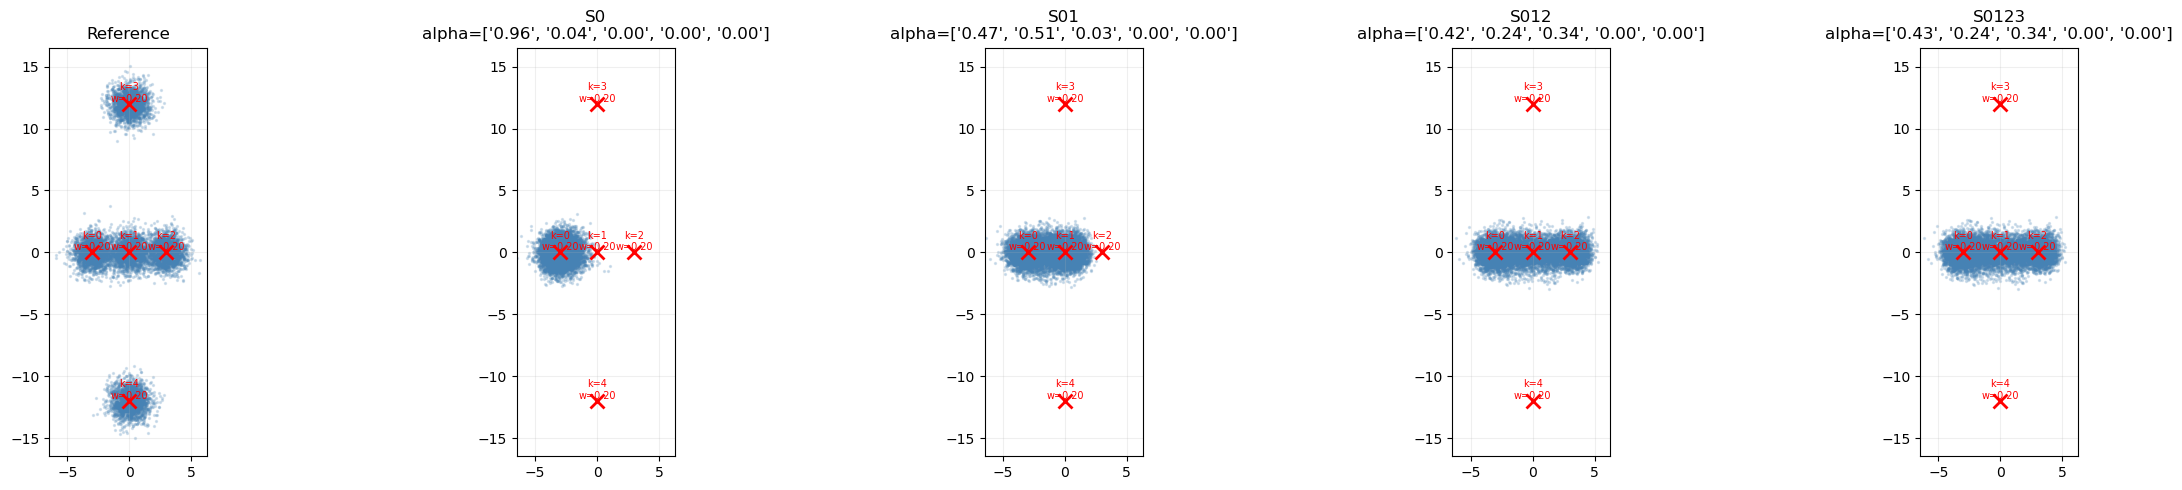

In [64]:
# ====== EDIT: pick experiment IDs to compare ======
EXP_IDS = [
    f"goal1_as_{BENCH_NAME}_S0_pretrain_seed0",
    f"goal1_as_{BENCH_NAME}_S01_pretrain_seed0",
    f"goal1_as_{BENCH_NAME}_S012_pretrain_seed0",
    f"goal1_as_{BENCH_NAME}_S0123_pretrain_seed0",
]
EPOCH = "500"  # "500" for pretrain, "200" for stability

from evaluation.utils.checkpoint_loader import load_sampler_from_checkpoint
from evaluation.utils.trajectory_sampler import sample_from_checkpoint

fig, axes = plt.subplots(1, len(EXP_IDS) + 1, figsize=(5 * (len(EXP_IDS) + 1), 5))

# Reference
bench_cfg = f"benchmark/configs/{BENCH_NAME}.yaml"  # match your experiments
efn = load_benchmark(bench_cfg)
ref = efn.get_ref_samples(N_EVAL)
plot_2d_samples(ref, efn, "Reference", ax=axes[0], s=2, alpha=0.2)

for i, exp_id in enumerate(EXP_IDS):
    try:
        samps = sample_from_checkpoint(exp_id, N_EVAL, epoch=EPOCH, device=str(device))
        subset_str = exp_id.split("_")[3]  # extract S part
        alphas_list = efn.mode_assignment(samps.to(device))
        counts = torch.bincount(alphas_list, minlength=efn.K).float()
        alpha_str = [f"{c/len(samps):.2f}" for c in counts]
        plot_2d_samples(samps, efn, f"{subset_str}\nalpha={alpha_str}", ax=axes[i+1], s=2, alpha=0.2)
    except Exception as e:
        axes[i+1].set_title(f"{exp_id}\nERROR: {e}", fontsize=8)

xlims = axes[0].get_xlim(); ylims = axes[0].get_ylim()
for ax in axes:
    ax.set_xlim(xlims); ax.set_ylim(ylims)
plt.tight_layout()
plt.show()

## 10b. Load & Visualize Stability Run Checkpoints
Load completed stability experiment checkpoints and visualize sample evolution across epochs.

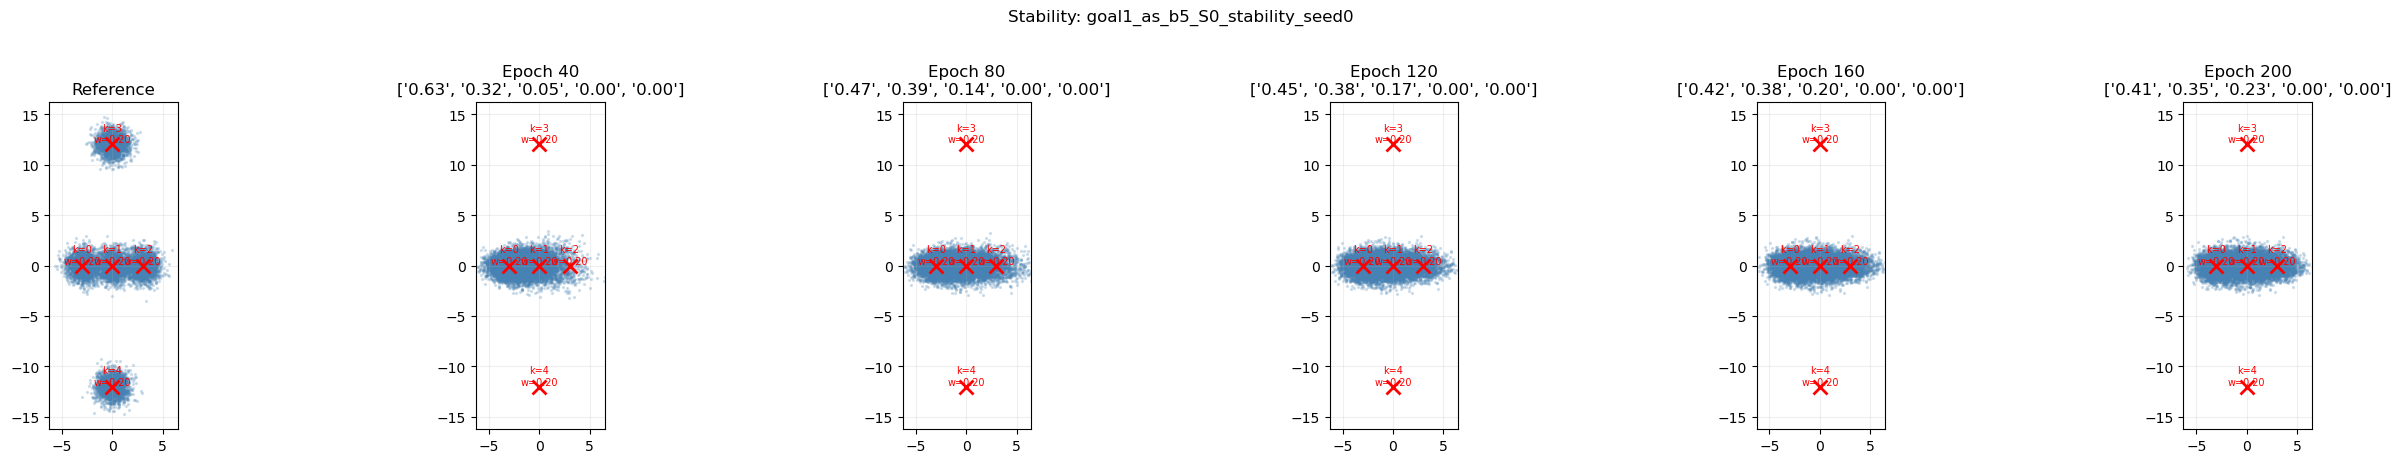

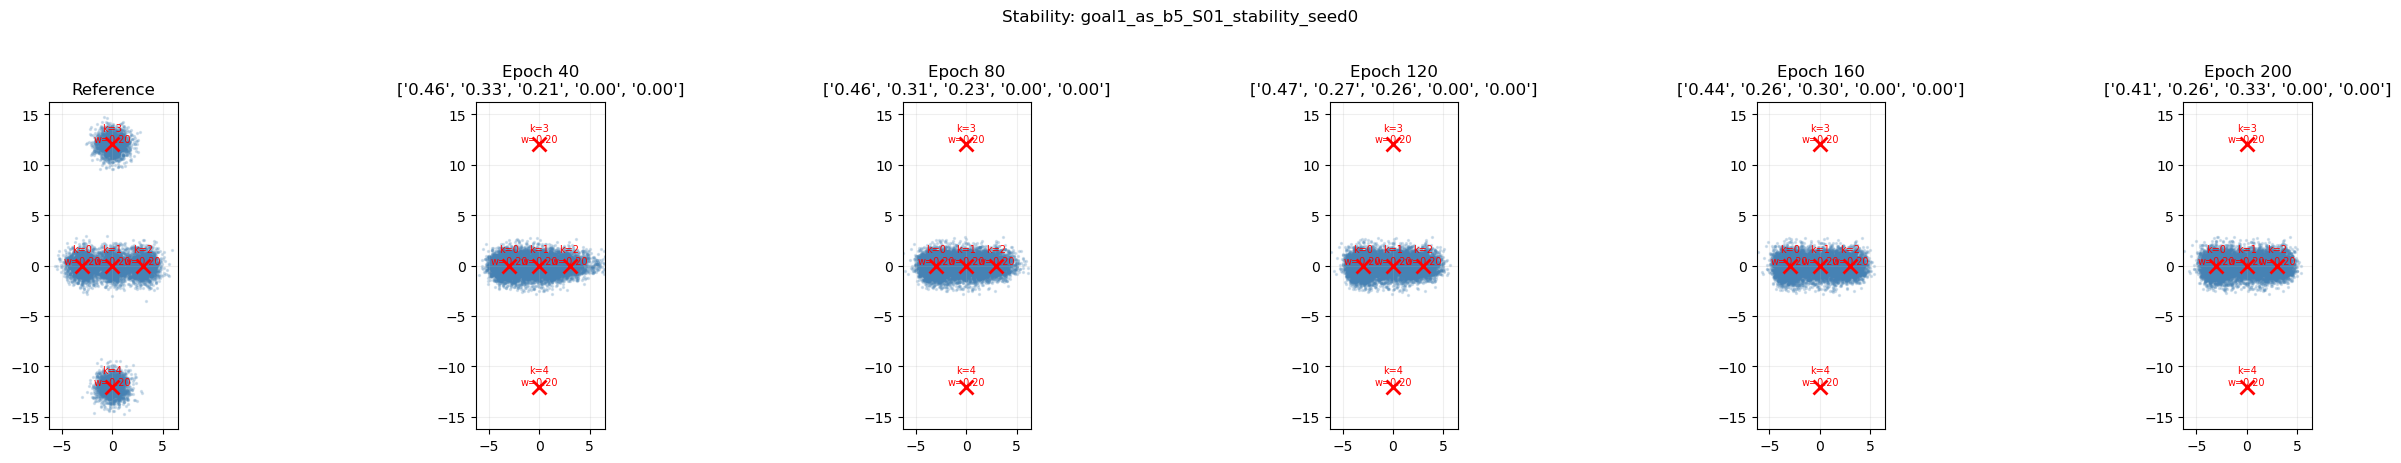

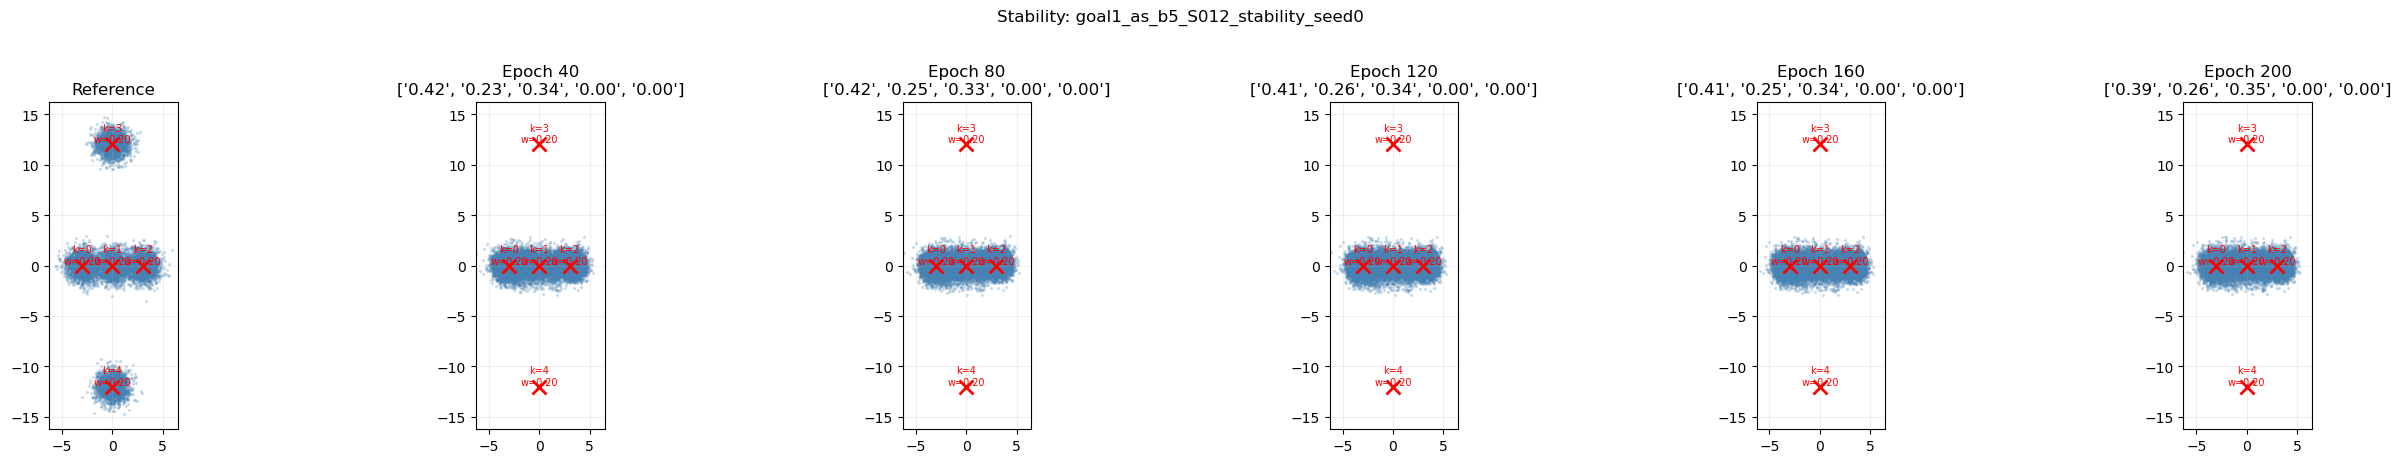

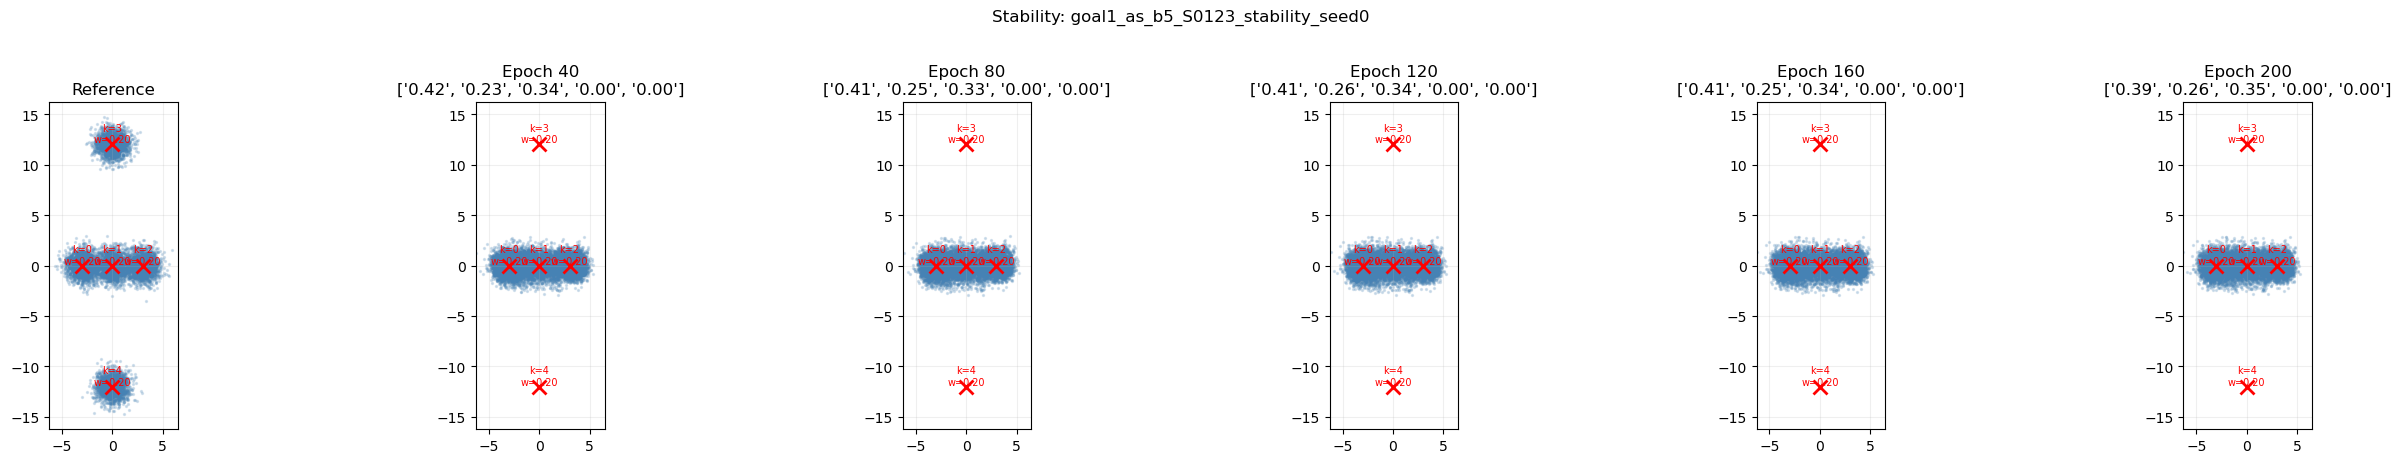

In [65]:
# ====== EDIT: pick stability experiment IDs ======
STABILITY_EXP_IDS = [
    f"goal1_as_{BENCH_NAME}_S0_stability_seed0",
    f"goal1_as_{BENCH_NAME}_S01_stability_seed0",
    f"goal1_as_{BENCH_NAME}_S012_stability_seed0",
    f"goal1_as_{BENCH_NAME}_S0123_stability_seed0",
]
STABILITY_EPOCHS = [40, 80, 120, 160, 200]  # checkpoints saved every 40 epochs

from evaluation.utils.checkpoint_loader import load_sampler_from_checkpoint
from evaluation.utils.trajectory_sampler import sample_from_checkpoint

bench_cfg_stab = f"benchmark/configs/{BENCH_NAME}.yaml"  # match your experiments
efn_stab = load_benchmark(bench_cfg_stab)
ref_stab = efn_stab.get_ref_samples(N_EVAL)

for exp_id in STABILITY_EXP_IDS:
    n_cols = 1 + len(STABILITY_EPOCHS)
    fig, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 4.5))

    # Reference panel
    plot_2d_samples(ref_stab, efn_stab, "Reference", ax=axes[0], s=2, alpha=0.2)

    for j, ep in enumerate(STABILITY_EPOCHS):
        try:
            samps = sample_from_checkpoint(exp_id, N_EVAL, epoch=str(ep), device=str(device))
            assignments = efn_stab.mode_assignment(samps.to(device))
            counts = torch.bincount(assignments, minlength=efn_stab.K).float()
            alpha_str = [f"{c/len(samps):.2f}" for c in counts]
            plot_2d_samples(samps, efn_stab, f"Epoch {ep}\n{alpha_str}", ax=axes[j+1], s=2, alpha=0.2)
        except Exception as e:
            axes[j+1].set_title(f"Epoch {ep}\n{e}", fontsize=7)

    xlims = axes[0].get_xlim(); ylims = axes[0].get_ylim()
    for ax in axes:
        ax.set_xlim(xlims); ax.set_ylim(ylims)

    subset_str = exp_id.split("_")[3]
    plt.suptitle(f"Stability: {exp_id}", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

## 11. KDE Density Comparison
Compare model density vs reference density as 2D KDE heatmaps.

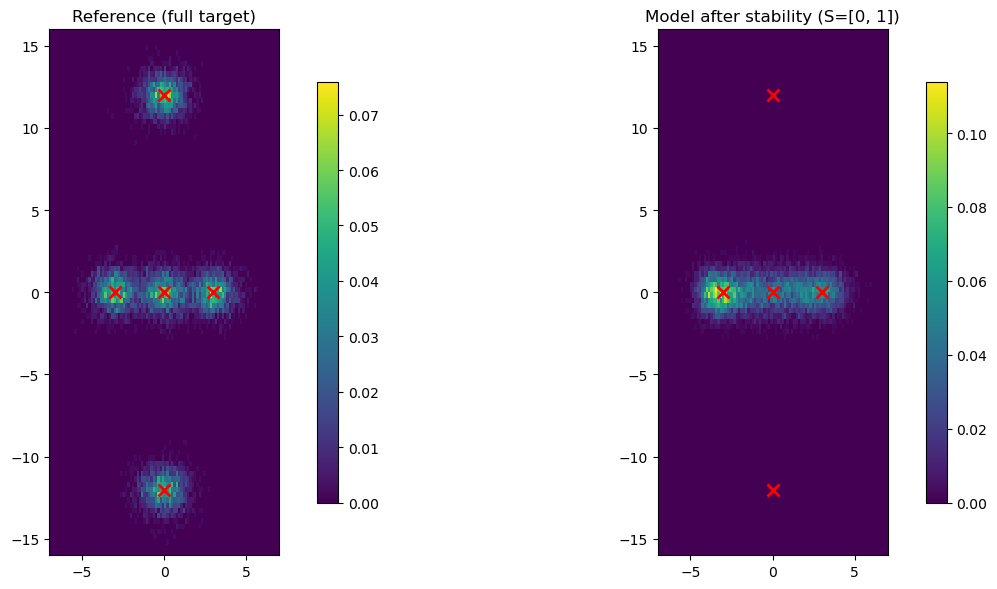

In [66]:
def plot_kde_comparison(ref_samples, model_samples, energy_fn, titles=("Reference", "Model"), bins=100):
    """Side-by-side 2D histogram density comparison."""
    centers = energy_fn.mode_centers.cpu().numpy()
    margin = 4.0
    xmin, xmax = centers[:, 0].min() - margin, centers[:, 0].max() + margin
    ymin, ymax = centers[:, 1].min() - margin, centers[:, 1].max() + margin

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, samps, title in zip(axes, [ref_samples, model_samples], titles):
        x = samps[:, 0].cpu().numpy()
        y = samps[:, 1].cpu().numpy()
        h = ax.hist2d(x, y, bins=bins, range=[[xmin, xmax], [ymin, ymax]],
                       cmap='viridis', density=True)
        plt.colorbar(h[3], ax=ax, shrink=0.8)
        for k, (cx, cy) in enumerate(centers):
            ax.plot(cx, cy, 'rx', markersize=8, markeredgewidth=2)
        ax.set_aspect('equal'); ax.set_title(title)
    plt.tight_layout()
    return fig

fig = plot_kde_comparison(
    ref_full.cpu(), final_samples.cpu(), energy_fn,
    titles=("Reference (full target)", f"Model after stability (S={SUBSET_S})")
)
plt.show()

## 12. Batch Comparison: All Singletons
Quickly visualize all |S|=1 pretrained checkpoints for a given benchmark.

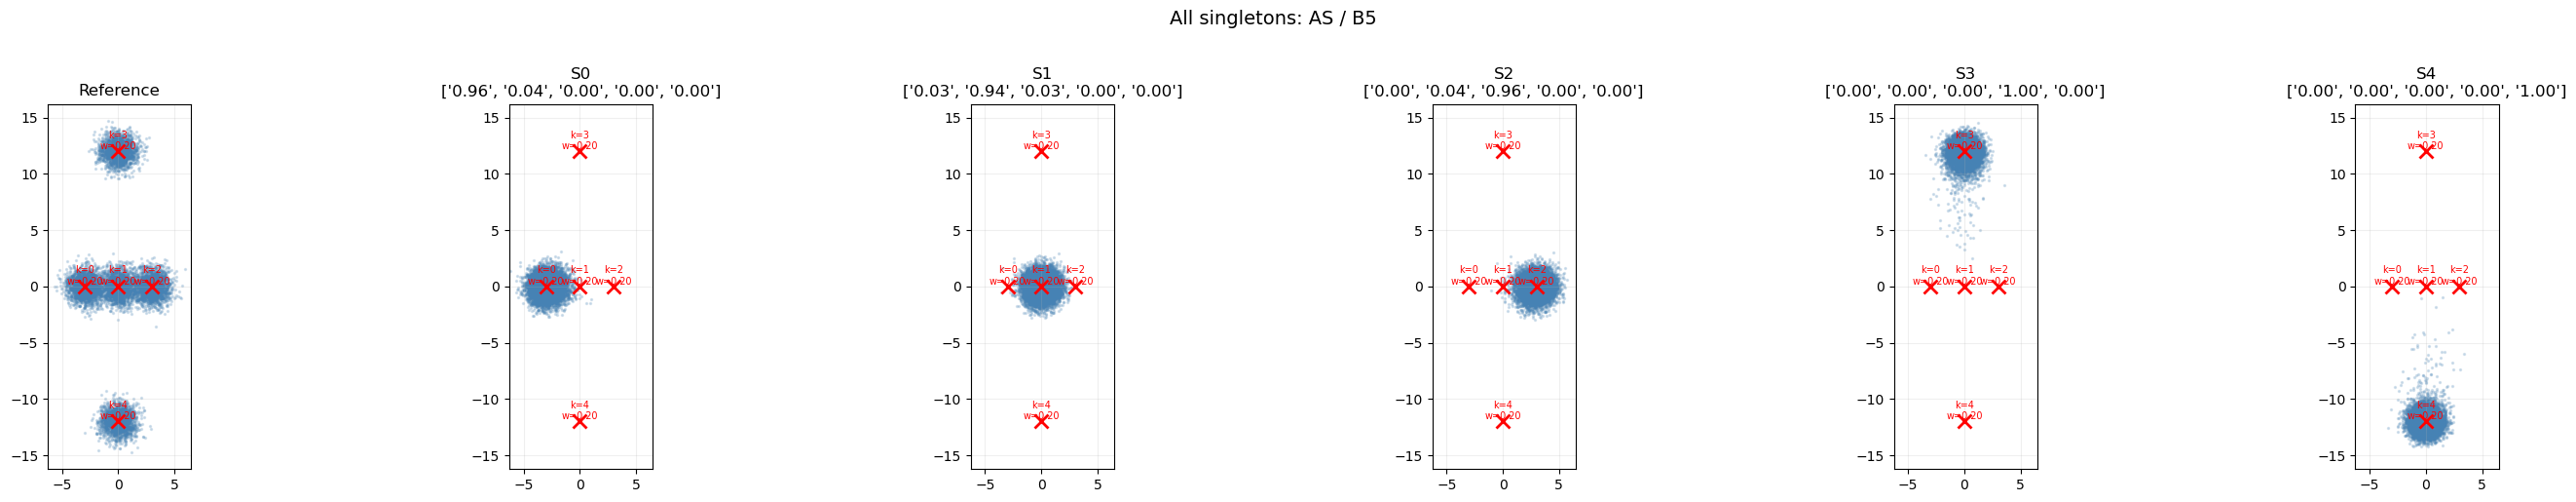

In [68]:
# ====== EDIT ======
COMPARE_SAMPLER = "as"
COMPARE_BENCH = BENCH_NAME
COMPARE_BENCH_CFG = f"benchmark/configs/{COMPARE_BENCH}.yaml"

efn = load_benchmark(COMPARE_BENCH_CFG)
ref = efn.get_ref_samples(N_EVAL)
singletons = [[k] for k in range(efn.K)]

fig, axes = plt.subplots(1, efn.K + 1, figsize=(5 * (efn.K + 1), 5))
plot_2d_samples(ref, efn, "Reference", ax=axes[0], s=2, alpha=0.2)

for i, S in enumerate(singletons):
    subset_str = "S" + "".join(str(k) for k in S)
    exp_id = f"goal1_{COMPARE_SAMPLER}_{COMPARE_BENCH}_{subset_str}_pretrain_seed0"
    try:
        samps = sample_from_checkpoint(exp_id, N_EVAL, epoch="500", device=str(device))
        assignments = efn.mode_assignment(samps.to(device))
        counts = torch.bincount(assignments, minlength=efn.K).float()
        alpha_str = [f"{c/len(samps):.2f}" for c in counts]
        plot_2d_samples(samps, efn, f"{subset_str}\n{alpha_str}", ax=axes[i+1], s=2, alpha=0.2)
    except Exception as e:
        axes[i+1].set_title(f"{subset_str}\n{e}", fontsize=7)

xlims = axes[0].get_xlim(); ylims = axes[0].get_ylim()
for ax in axes: ax.set_xlim(xlims); ax.set_ylim(ylims)
plt.suptitle(f"All singletons: {COMPARE_SAMPLER.upper()} / {COMPARE_BENCH.upper()}", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 13. Save Figures
Export any figure from above to disk.

In [38]:
# # Re-create and save any figure. Example: terminal distribution evolution
# snapshots_save = {"e=0 (pretrain)": samples_pretrain.cpu()}
# for e, samps in sorted(stability_samples.items()):
#     snapshots_save[f"e={e}"] = samps

# n = 1 + len(snapshots_save)
# fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5))
# plot_2d_samples(ref_full, energy_fn, "Reference", ax=axes[0], s=1, alpha=0.15)
# for i, (label, samps) in enumerate(snapshots_save.items()):
#     plot_2d_samples(samps, energy_fn, label, ax=axes[i+1], s=1, alpha=0.15)
# xlims = axes[0].get_xlim(); ylims = axes[0].get_ylim()
# for ax in axes: ax.set_xlim(xlims); ax.set_ylim(ylims)
# plt.suptitle(f"{SAMPLER_NAME.upper()} / {BENCH_NAME.upper()} / S={SUBSET_S}", fontsize=13, y=1.01)
# plt.tight_layout()

# save_path = f"evaluation/figures/playground_{SAMPLER_NAME}_{BENCH_NAME}_S{''.join(map(str,SUBSET_S))}_evolution.png"
# fig.savefig(save_path, dpi=150, bbox_inches='tight')
# print(f"Saved: {save_path}")
# plt.show()